In [477]:
# !pip install plotly

# Carregando a base de dados

In [478]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression                           
from sklearn.metrics import mean_absolute_error, r2_score 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from prophet import Prophet

In [479]:
ibovespa = pd.read_csv(r"../data/trusted/ibovespa_historico.csv", sep=';')
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,alta,5.2109
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,baixa,5.2359
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,baixa,5.2196
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,baixa,5.2120
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,alta,5.1836


In [480]:
# Quais os tipos informações compõe o banco de dados (base original)
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   data                 534 non-null    str    
 1   abertura             534 non-null    float64
 2   maxima               534 non-null    float64
 3   minima               534 non-null    float64
 4   fechamento           534 non-null    float64
 5   vol_reais            534 non-null    float64
 6   variacao_percentual  534 non-null    float64
 7   status               534 non-null    str    
 8   cotacao_dia_dolar    534 non-null    float64
dtypes: float64(7), str(2)
memory usage: 37.7 KB


# EDA - Análise Exploratória de Dados

In [481]:
# Instanciando
le = LabelEncoder()
ibovespa["status_encoded"] = le.fit_transform(ibovespa["status"])

In [482]:
ibovespa.describe()

,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,cotacao_dia_dolar,status_encoded
count,534.000000,534.000000,534.000000,534.000000,5.340000e+02,534.000000,534.000000,534.000000
mean,135.653060,136.561036,134.888457,135.754279,4.858124e+09,0.067959,5.473749,0.473783
std,13.813322,14.069473,13.746830,14.000180,4.948503e+09,0.916199,0.303307,0.499780
min,118.534000,119.451000,118.223000,118.533000,4.330000e+06,-4.310000,4.853900,0.000000
25%,127.223000,127.871250,126.448750,127.227500,9.370000e+06,-0.447500,5.300125,0.000000
50%,131.168000,131.867500,130.424000,131.168500,6.020000e+09,0.050000,5.472000,0.000000
75%,138.852250,139.396500,137.987500,138.879750,9.180000e+09,0.590000,5.674450,1.000000
max,189.694000,190.561000,186.959000,189.699000,2.487000e+10,3.330000,6.289600,1.000000


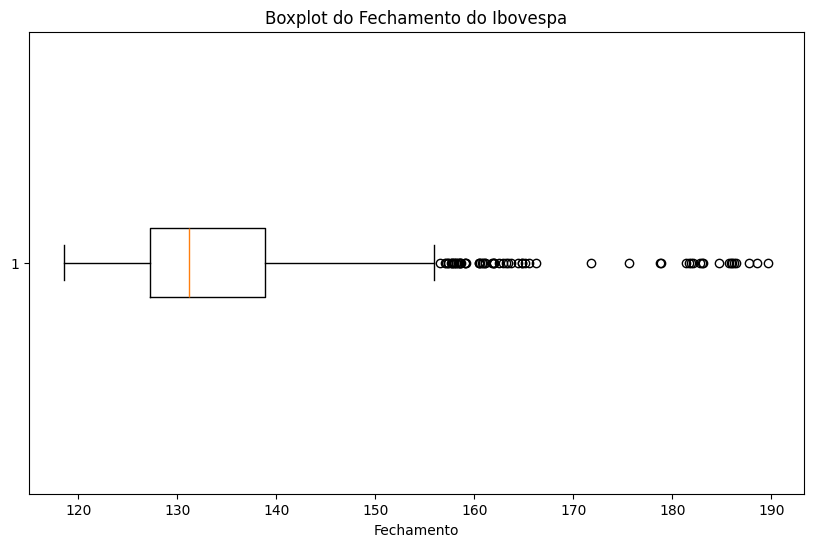

In [483]:
plt.figure(figsize=(10, 6))
plt.boxplot(ibovespa['fechamento'], vert=False)
plt.title('Boxplot do Fechamento do Ibovespa')
plt.xlabel('Fechamento')
plt.show()

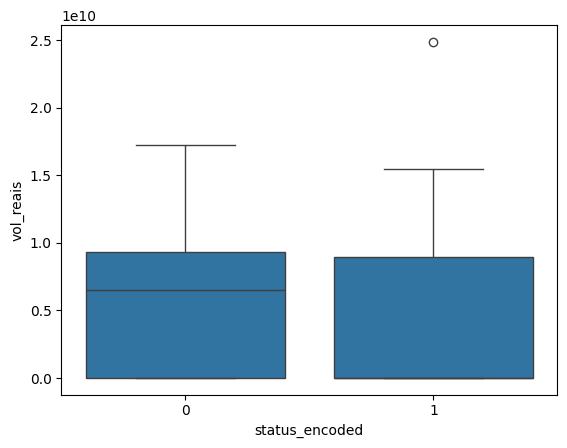

In [484]:
sns.boxplot(x="status_encoded", y="vol_reais", data=ibovespa)
plt.show()

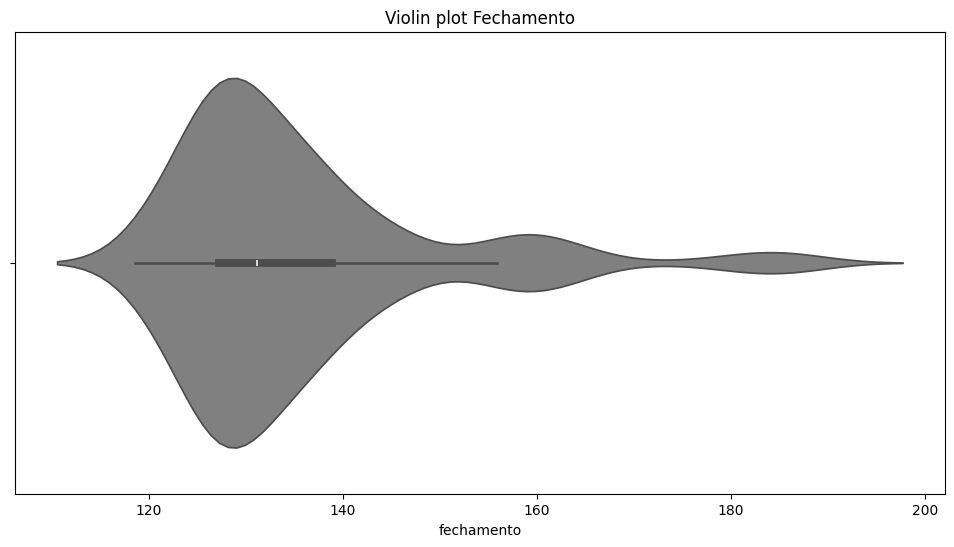

In [485]:
#Criando o subplot do boxplot, para configurarmos o tamanho
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="fechamento", data=ibovespa, color="gray")
axes.set_title('Violin plot Fechamento')
plt.show()

In [486]:
# Transformando a coluna Data de objeto para data
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded
0,2026-02-19,186.020,188.687,185.928,188.534,9.240000e+09,1.35,alta,5.2109,0
1,2026-02-18,186.464,187.657,185.001,186.016,7.790000e+09,-0.24,baixa,5.2359,1
2,2026-02-13,187.766,187.766,183.662,186.464,1.159000e+10,-0.69,baixa,5.2196,1
3,2026-02-12,189.694,189.990,186.959,187.766,1.236000e+10,-1.02,baixa,5.2120,1
4,2026-02-11,185.936,190.561,185.936,189.699,1.164000e+10,2.03,alta,5.1836,0


In [487]:
# Quantidade de dados nulos por coluna
ibovespa.isnull().sum()

data                   0
abertura               0
maxima                 0
minima                 0
fechamento             0
vol_reais              0
variacao_percentual    0
status                 0
cotacao_dia_dolar      0
status_encoded         0
dtype: int64

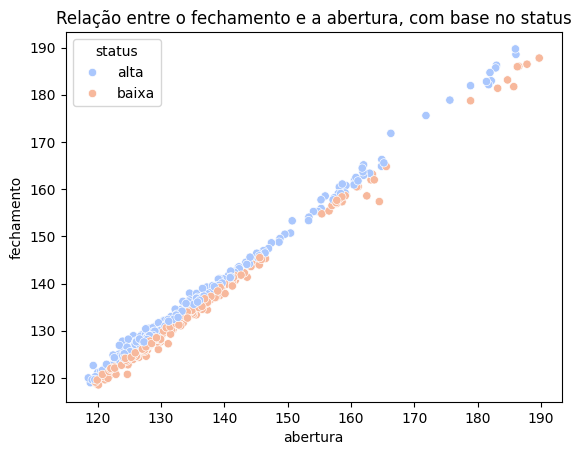

In [488]:

#Vamos verificar ambas coluna gerando um gráfico de dispersão
sns.scatterplot(x='abertura', y='fechamento', hue='status', data=ibovespa, palette='coolwarm')
plt.xlabel('abertura')
plt.ylabel('fechamento')
plt.title('Relação entre o fechamento e a abertura, com base no status')
plt.show()

In [489]:
# Validando a saída final da base
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 534 non-null    datetime64[us]
 1   abertura             534 non-null    float64       
 2   maxima               534 non-null    float64       
 3   minima               534 non-null    float64       
 4   fechamento           534 non-null    float64       
 5   vol_reais            534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   status               534 non-null    str           
 8   cotacao_dia_dolar    534 non-null    float64       
 9   status_encoded       534 non-null    int64         
dtypes: datetime64[us](1), float64(7), int64(1), str(1)
memory usage: 41.8 KB


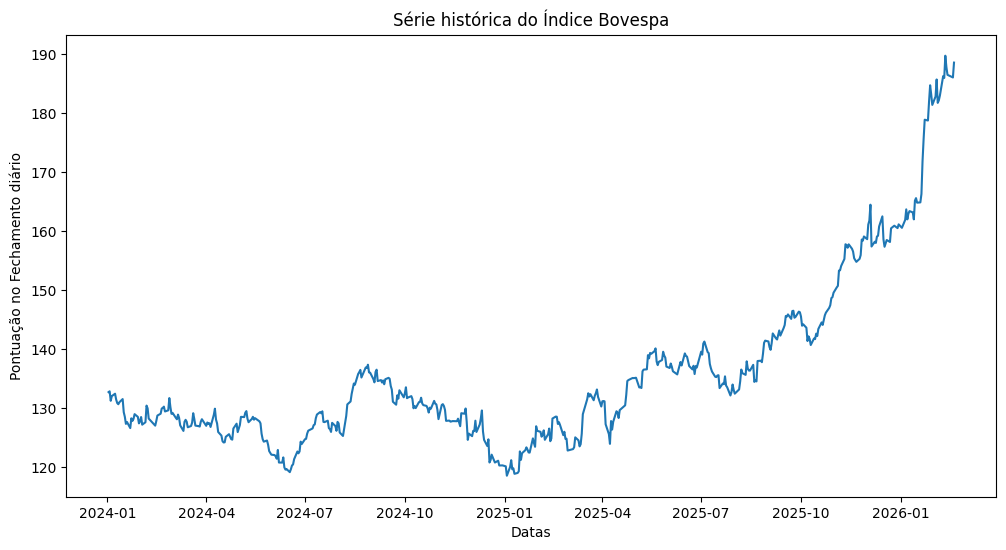

In [490]:
# Análise temporal (série histórica)
plt.figure(figsize=(12, 6))
plt.plot(ibovespa["data"], ibovespa["fechamento"])
plt.xlabel("Datas")
plt.ylabel("Pontuação no Fechamento diário")
plt.title("Série histórica do Índice Bovespa")
plt.show()

In [491]:
# Transformando a coluna vol_reais para logaritmo, para tentar reduzir a influência de outliers

ibovespa["vol_log"] = np.log(ibovespa["vol_reais"])

In [492]:
ibovespa = ibovespa.sort_values("data")

In [493]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log
533,2024-01-02,134.186,134.195,132.095,132.697,8440000.0,-1.11,baixa,4.9235,1,15.948493
532,2024-01-03,132.697,133.576,132.250,132.834,8700000.0,0.10,alta,4.9198,0,15.978834
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577


## Testando o modelo SVC ❌

In [494]:
ibovespa["target_next"] = ibovespa["status_encoded"].shift(-1)

ibovespa["fechamento_lag1"] = ibovespa["fechamento"].shift(1)
ibovespa["vol_lag1"] = ibovespa["vol_log"].shift(1)
ibovespa["dolar_lag1"] = ibovespa["cotacao_dia_dolar"].shift(1)

ibovespa = ibovespa.dropna()

X = ibovespa[[
    "fechamento_lag1",
    "vol_lag1",
    "dolar_lag1"
]]

y = ibovespa["target_next"]

In [495]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

In [496]:
tscv = TimeSeriesSplit(n_splits=5)

In [497]:
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Acurácia:", acc)

Acurácia: 0.5681818181818182
Acurácia: 0.4431818181818182
Acurácia: 0.5
Acurácia: 0.5568181818181818
Acurácia: 0.3522727272727273


## Testando o modelo XGBoost ❌

In [498]:
ibovespa["target_next"] = ibovespa["status_encoded"].shift(-1)

ibovespa["fechamento_lag1"] = ibovespa["fechamento"].shift(1)
ibovespa["vol_lag1"] = ibovespa["vol_log"].shift(1)
ibovespa["dolar_lag1"] = ibovespa["cotacao_dia_dolar"].shift(1)

ibovespa = ibovespa.dropna()

X = ibovespa[[
    "fechamento_lag1",
    "vol_lag1",
    "dolar_lag1"
]]

y = ibovespa["target_next"]

tscv = TimeSeriesSplit(n_splits=5)

In [499]:
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Acurácia:", acc)

Acurácia: 0.5568181818181818
Acurácia: 0.45454545454545453
Acurácia: 0.4772727272727273
Acurácia: 0.5340909090909091
Acurácia: 0.4659090909090909


## Testando o modelo LogisticRegression ❌

In [500]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=False  # importante em séries temporais
)

In [501]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 1.0

Relatório de Classificação:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00        68

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159



## Testando o modelo KNN  ✅

In [502]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

Testando o melhor neighbors K

In [503]:
K = 0

for k in range(1, 21):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipeline.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipeline.predict(X_test))
    if acc > 0.7 and acc < 0.9: K = k
    print(k, acc)

1 0.9
2 0.9
3 1.0
4 0.8666666666666667
5 1.0
6 0.9
7 0.9
8 0.9
9 0.9
10 0.9
11 1.0
12 0.9666666666666667
13 1.0
14 0.9333333333333333
15 1.0
16 0.9
17 1.0
18 0.9
19 0.9
20 0.7666666666666667


In [504]:
# Testando o modelo com k=3, para verificar a acurácia



pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=K))
    ])
pipeline.fit(X_train, y_train)
acc = accuracy_score(y_test, pipeline.predict(X_test))
print("Vizinhos: {0}".format(K), "Acurácia:", acc)

Vizinhos: 20 Acurácia: 0.7666666666666667


# Testando o modelo Regressao Linear Minimo Escalado ❌

In [505]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log,target_next,fechamento_lag1,vol_lag1,dolar_lag1
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396,0.0,132.834,15.978834,4.9198
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714,0.0,131.226,16.009396,4.8968
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577,1.0,132.023,16.034714,4.8743
528,2024-01-09,132.424,132.426,131.203,131.447,9290000.0,-0.74,baixa,4.9038,1,16.044449,1.0,132.427,15.955577,4.8700
527,2024-01-10,131.447,131.628,130.438,130.841,8960000.0,-0.46,baixa,4.8909,1,16.008281,1.0,131.447,16.044449,4.9038


In [506]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

scaler = MinMaxScaler()

scaler.fit(X_train)

x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [507]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [508]:
# Fazendo as previsões
y_pred = model.predict(x_test_scaled)

In [509]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MAE',MAE)
print('r²',r2)

MAE 2.3929083785591687e-16
r² 1.0


# Testando o modelo Regressao Linear ❌

In [510]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log,target_next,fechamento_lag1,vol_lag1,dolar_lag1
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396,0.0,132.834,15.978834,4.9198
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714,0.0,131.226,16.009396,4.8968
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577,1.0,132.023,16.034714,4.8743
528,2024-01-09,132.424,132.426,131.203,131.447,9290000.0,-0.74,baixa,4.9038,1,16.044449,1.0,132.427,15.955577,4.8700
527,2024-01-10,131.447,131.628,130.438,130.841,8960000.0,-0.46,baixa,4.8909,1,16.008281,1.0,131.447,16.044449,4.9038


In [511]:
X = ibovespa.drop(columns=["status", "data", "vol_reais", "variacao_percentual"])
y = ibovespa["status_encoded"]

X_train = X.iloc[:-30]
X_test  = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test  = y.iloc[-30:]

In [512]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [513]:
y_pred = model.predict(X_test)
r_sq = model.score(X, y)

print('Coeficiente de Determinação (R²):', r_sq)

Coeficiente de Determinação (R²): 1.0


In [514]:
print('Intercepto:', model.intercept_)

Intercepto: 2.5202062658991053e-14


# Testando o modelo RandomForestClassifier ❌

In [515]:
ibovespa.head()

,data,abertura,maxima,minima,fechamento,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log,target_next,fechamento_lag1,vol_lag1,dolar_lag1
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396,0.0,132.834,15.978834,4.9198
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714,0.0,131.226,16.009396,4.8968
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577,1.0,132.023,16.034714,4.8743
528,2024-01-09,132.424,132.426,131.203,131.447,9290000.0,-0.74,baixa,4.9038,1,16.044449,1.0,132.427,15.955577,4.8700
527,2024-01-10,131.447,131.628,130.438,130.841,8960000.0,-0.46,baixa,4.8909,1,16.008281,1.0,131.447,16.044449,4.9038


In [516]:
df = ibovespa.sort_values("ds")

# Separar últimos 30 dias como teste
df_train = df.iloc[:-30]
df_test  = df.iloc[-30:]

# Features (remover colunas que vazam informação)
features = [
    "abertura",
    "maxima",
    "minima",
    "fechamento_lag1",
    "vol_lag1",
    "dolar_lag1",
    "vol_log",
]

X_train = df_train[features]
y_train = df_train["target_next"]

X_test = df_test[features]
y_test = df_test["target_next"]

KeyError: 'ds'

Ajustamos o RandomForestClassifier mesmo com os hiperparametros ainda não conseguimos atingir o objetivo.

In [ ]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Melhores parâmetros:", grid.best_params_)

best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Acurácia final:", acc)

Acurácia: 0.4666666666666667
              precision    recall  f1-score   support

         0.0       0.75      0.17      0.27        18
         1.0       0.42      0.92      0.58        12

    accuracy                           0.47        30
   macro avg       0.59      0.54      0.43        30
weighted avg       0.62      0.47      0.40        30



# Testando o Modelo TimeSeries ⚠️

Talvez não usariamos porque seu resultado está mais contido em uma serie temporal futura indicando uma direção do que de fato uma direção Alta ou Baixa na Ibovespa

In [ ]:
ibovespa.rename(columns={"data": "ds", "fechamento": "y"}, inplace=True)
ibovespa.head()

,ds,abertura,maxima,minima,y,vol_reais,variacao_percentual,status,cotacao_dia_dolar,status_encoded,vol_log,target_next,fechamento_lag1,vol_lag1,dolar_lag1
531,2024-01-04,132.831,132.885,131.024,131.226,8970000.0,-1.21,baixa,4.8968,1,16.009396,0.0,132.834,15.978834,4.9198
530,2024-01-05,131.218,132.635,130.579,132.023,9200000.0,0.61,alta,4.8743,0,16.034714,0.0,131.226,16.009396,4.8968
529,2024-01-08,132.023,132.498,131.015,132.427,8500000.0,0.31,alta,4.8700,0,15.955577,1.0,132.023,16.034714,4.8743
528,2024-01-09,132.424,132.426,131.203,131.447,9290000.0,-0.74,baixa,4.9038,1,16.044449,1.0,132.427,15.955577,4.8700
527,2024-01-10,131.447,131.628,130.438,130.841,8960000.0,-0.46,baixa,4.8909,1,16.008281,1.0,131.447,16.044449,4.9038


22:22:47 - cmdstanpy - INFO - Chain [1] start processing
22:22:48 - cmdstanpy - INFO - Chain [1] done processing


MAE: 4.8815686772748395
RMSE: 5.759545054808885
MAPE: 2.852668248255036


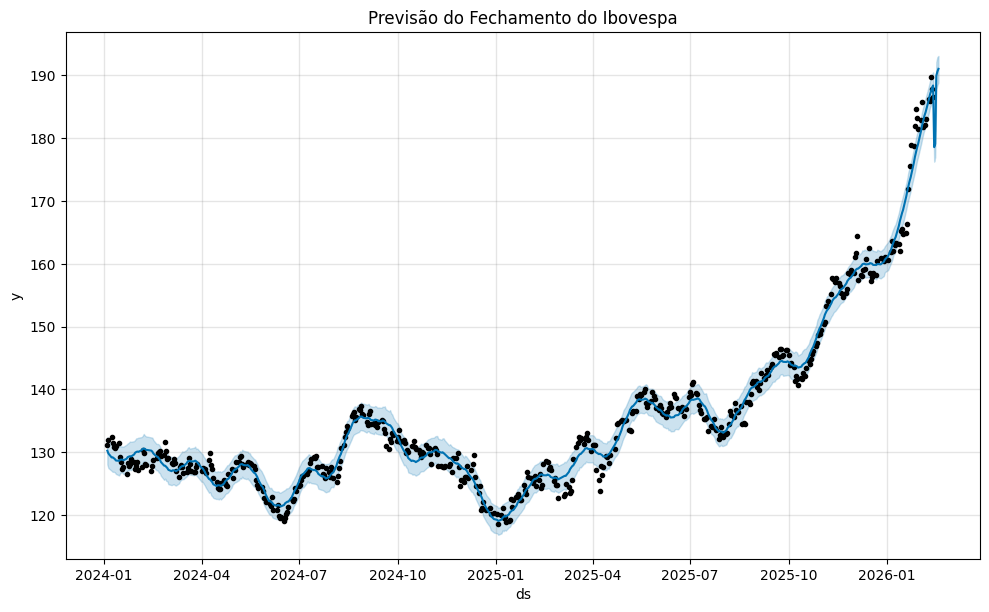

In [ ]:


m = Prophet()
m.fit(ibovespa[["ds", "y"]])

# Separação temporal
train = ibovespa.iloc[:-30]
test  = ibovespa.iloc[-30:]

future = m.make_future_dataframe(periods=5)
future.tail()

forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

fig1 = m.plot(forecast)
plt.title("Previsão do Fechamento do Ibovespa")

# Pegar apenas previsão dos últimos 30 dias
forecast_test = forecast[['ds','yhat']].iloc[-30:]

test = test.reset_index(drop=True)
forecast_test = forecast_test.reset_index(drop=True)

# Métricas
mae = mean_absolute_error(test['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))
mape = np.mean(np.abs((test['y'] - forecast_test['yhat']) / test['y'])) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

